## 1. Importação de Bibliotecas

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score, recall_score,
    accuracy_score, precision_score,
    roc_auc_score,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 2. Carregamento e Preparação dos Dados

In [9]:
df = pd.read_csv('urldata_features.csv')

colunas_excluir = ['domain', 'ranking', 'label']
X = df.drop(columns=colunas_excluir)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features : {X.shape[1]}')
print(f'Treino   : {X_train.shape[0]:,} instâncias')
print(f'Teste    : {X_test.shape[0]:,} instâncias')

Features : 21
Treino   : 76,728 instâncias
Teste    : 19,183 instâncias


## 3. Desempenho Baseline

In [10]:
# Treinar modelo base (mesmos parâmetros do Passo 3)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

baseline = {
    'Accuracy' : accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall'   : recall_score(y_test, y_pred_base),
    'F1-Score' : f1_score(y_test, y_pred_base),
    'AUC-ROC'  : roc_auc_score(y_test, rf_base.predict_proba(X_test)[:,1]),
}

print('Desempenho BASELINE (n_estimators=100, parametros padrao):')
for metrica, valor in baseline.items():
    print(f'  {metrica:<12}: {valor*100:.2f}%')

Desempenho BASELINE (n_estimators=100, parametros padrao):
  Accuracy    : 94.68%
  Precision   : 95.46%
  Recall      : 93.82%
  F1-Score    : 94.63%
  AUC-ROC     : 98.79%


## 4. Definição do Espaço de Hiperparâmetros

In [11]:
espaco_parametros = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30, 40],
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight'     : [None, 'balanced'],
}

# Total de combinações possíveis
total = 1
for k, v in espaco_parametros.items():
    total *= len(v)
    print(f'  {k:<20}: {len(v)} opções -> {v}')
print(f'\nTotal de combinações possíveis : {total:,}')
print(f'Combinações a testar (n_iter=30): 30')
print(f'Estimativa de tempo            : 15-30 minutos')

  n_estimators        : 4 opções -> [100, 200, 300, 500]
  max_depth           : 5 opções -> [None, 10, 20, 30, 40]
  max_features        : 4 opções -> ['sqrt', 'log2', 0.3, 0.5]
  min_samples_split   : 3 opções -> [2, 5, 10]
  min_samples_leaf    : 3 opções -> [1, 2, 4]
  class_weight        : 2 opções -> [None, 'balanced']

Total de combinações possíveis : 1,440
Combinações a testar (n_iter=30): 30
Estimativa de tempo            : 15-30 minutos


## 5. RandomizedSearchCV

In [14]:
inicio = time.time()

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=espaco_parametros,
    n_iter=50,           # testar 30 combinações aleatórias
    cv=5,                # validação cruzada de 5 folds
    scoring='f1',        # otimizar F1-Score
    random_state=42,
    n_jobs=-1,           # usar todos os núcleos
    verbose=2            # mostrar progresso
)

rf_search.fit(X_train, y_train)
tempo_total = time.time() - inicio

print(f'\nOtimização concluída em {tempo_total/60:.1f} minutos!')
print(f'\nMelhores parâmetros encontrados:')
for param, valor in rf_search.best_params_.items():
    print(f'  {param:<22}: {valor}')
print(f'\nMelhor F1-Score (cross-val): {rf_search.best_score_*100:.2f}%')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Otimização concluída em 18.5 minutos!

Melhores parâmetros encontrados:
  n_estimators          : 500
  min_samples_split     : 5
  min_samples_leaf      : 1
  max_features          : 0.5
  max_depth             : None
  class_weight          : None

Melhor F1-Score (cross-val): 94.25%


## 6. Avaliação do Modelo Otimizado

In [15]:
modelo_otimizado = rf_search.best_estimator_
y_pred_otim = modelo_otimizado.predict(X_test)
y_proba_otim = modelo_otimizado.predict_proba(X_test)[:, 1]

otimizado = {
    'Accuracy' : accuracy_score(y_test, y_pred_otim),
    'Precision': precision_score(y_test, y_pred_otim),
    'Recall'   : recall_score(y_test, y_pred_otim),
    'F1-Score' : f1_score(y_test, y_pred_otim),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_otim),
}

print('Desempenho MODELO OTIMIZADO:')
for metrica, valor in otimizado.items():
    print(f'  {metrica:<12}: {valor*100:.2f}%')

Desempenho MODELO OTIMIZADO:
  Accuracy    : 94.83%
  Precision   : 95.50%
  Recall      : 94.09%
  F1-Score    : 94.79%
  AUC-ROC     : 98.84%


## 7. Comparação Antes vs. Depois da Otimização

In [16]:
print(f'  {"Métrica":<12}  {"Baseline":>10}  {"Otimizado":>11}  {"Diferença":>11}')
print('  ' + '-' * 50)
for metrica in baseline:
    base = baseline[metrica]
    otim = otimizado[metrica]
    diff = otim - base
    sinal = '+' if diff >= 0 else ''
    print(f'  {metrica:<12}  {base*100:>9.2f}%  {otim*100:>10.2f}%  {sinal}{diff*100:>9.2f}%')

  Métrica         Baseline    Otimizado    Diferença
  --------------------------------------------------
  Accuracy          94.68%       94.83%  +     0.15%
  Precision         95.46%       95.50%  +     0.04%
  Recall            93.82%       94.09%  +     0.27%
  F1-Score          94.63%       94.79%  +     0.16%
  AUC-ROC           98.79%       98.84%  +     0.05%


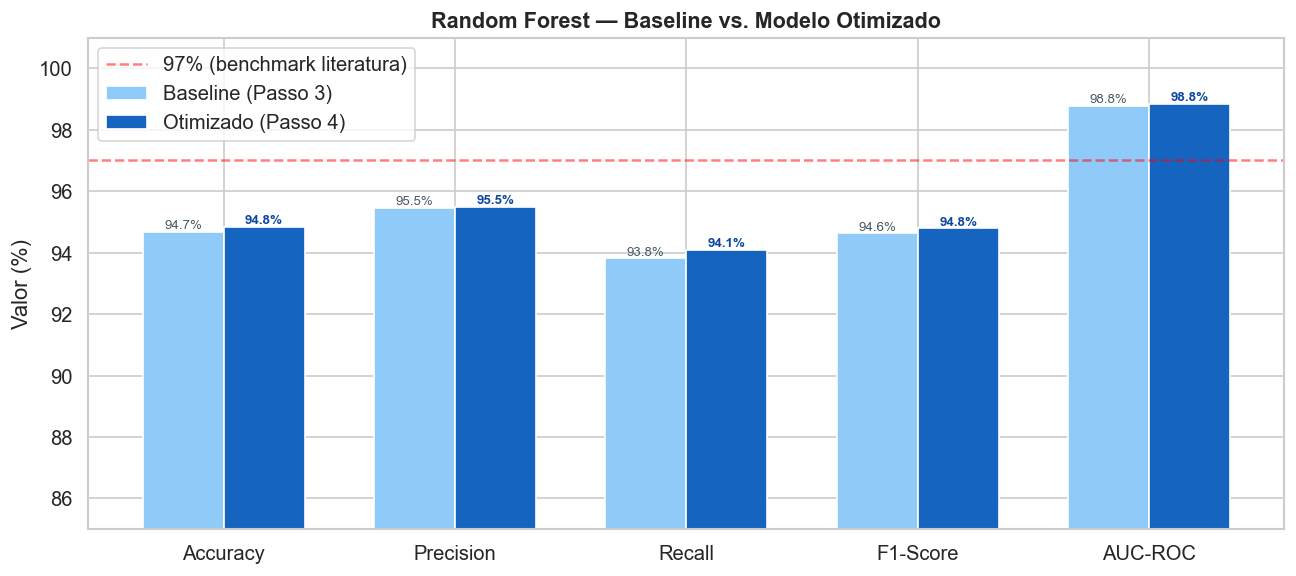

In [17]:
# Gráfico comparativo
metricas = list(baseline.keys())
vals_base = [baseline[m]*100 for m in metricas]
vals_otim = [otimizado[m]*100 for m in metricas]

x = np.arange(len(metricas))
largura = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - largura/2, vals_base, largura,
            label='Baseline (Passo 3)', color='#90caf9', edgecolor='white')
b2 = ax.bar(x + largura/2, vals_otim, largura,
            label='Otimizado (Passo 4)', color='#1565c0', edgecolor='white')

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, color='#455a64')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8,
            color='#0d47a1', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(85, 101)
ax.set_ylabel('Valor (%)')
ax.set_title('Random Forest — Baseline vs. Modelo Otimizado',
             fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(y=97, color='red', linestyle='--', alpha=0.5,
           label='97% (benchmark literatura)')
ax.legend()
plt.tight_layout()
plt.savefig('fig10_baseline_vs_otimizado.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Matriz de Confusão — Comparação

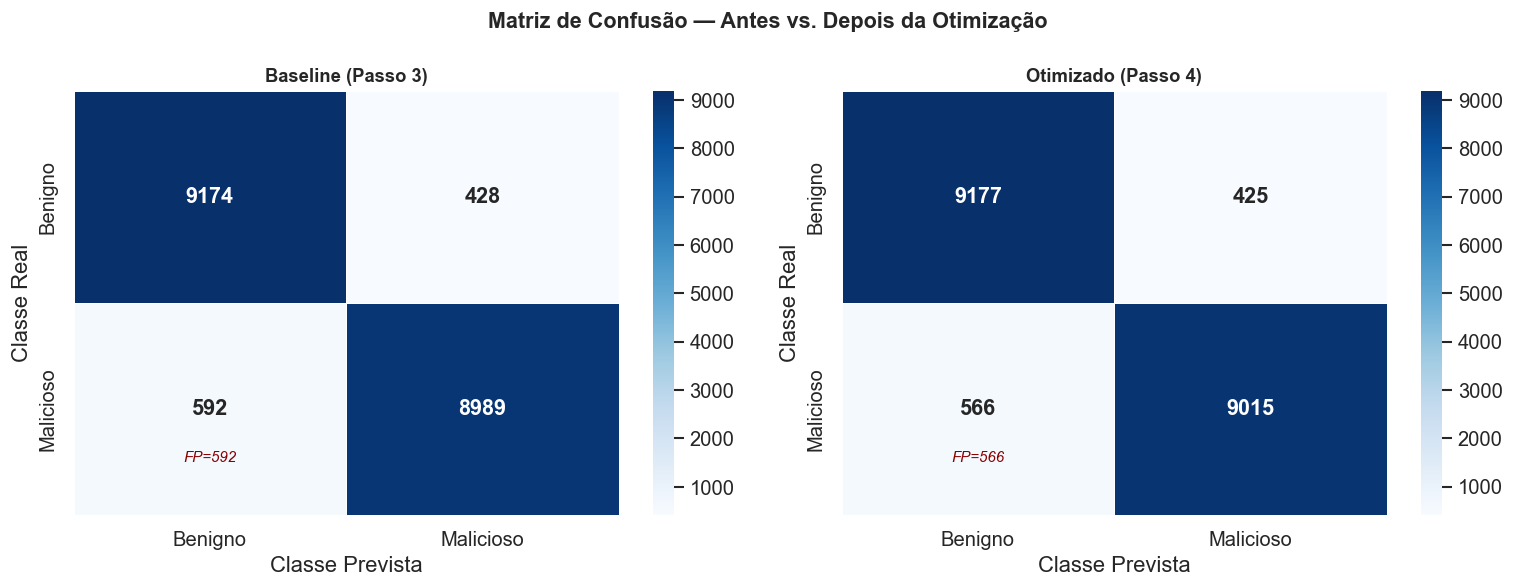

Falsos Positivos (FP) — Baseline  : 592
Falsos Positivos (FP) — Otimizado : 566
Redução de FP                     : 26


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_base, y_pred_otim],
    ['Baseline (Passo 3)', 'Otimizado (Passo 4)']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benigno', 'Malicioso'],
                yticklabels=['Benigno', 'Malicioso'],
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_xlabel('Classe Prevista')
    ax.set_ylabel('Classe Real')
    ax.set_title(titulo, fontweight='bold', fontsize=11)

    # FP destacado
    fp = cm[1, 0]
    ax.text(0.5, 1.75, f'FP={fp}', ha='center', fontsize=9,
            color='darkred', style='italic')

plt.suptitle('Matriz de Confusão — Antes vs. Depois da Otimização',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig11_confusao_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

cm_base = confusion_matrix(y_test, y_pred_base)
cm_otim = confusion_matrix(y_test, y_pred_otim)
print(f'Falsos Positivos (FP) — Baseline  : {cm_base[1,0]:,}')
print(f'Falsos Positivos (FP) — Otimizado : {cm_otim[1,0]:,}')
print(f'Redução de FP                     : {cm_base[1,0] - cm_otim[1,0]:,}')

## 9. Validação Cruzada do Modelo Otimizado

In [19]:
print('A executar validação cruzada (5-Fold)... pode demorar alguns minutos.')

scores_f1  = cross_val_score(modelo_otimizado, X, y, cv=5, scoring='f1',       n_jobs=-1)
scores_acc = cross_val_score(modelo_otimizado, X, y, cv=5, scoring='accuracy',  n_jobs=-1)
scores_auc = cross_val_score(modelo_otimizado, X, y, cv=5, scoring='roc_auc',   n_jobs=-1)

print('\nResultados da Validação Cruzada (5-Fold):')
print(f'  F1-Score  : {scores_f1.mean()*100:.2f}%  (± {scores_f1.std()*100:.2f}%)')
print(f'  Accuracy  : {scores_acc.mean()*100:.2f}%  (± {scores_acc.std()*100:.2f}%)')
print(f'  AUC-ROC   : {scores_auc.mean()*100:.2f}%  (± {scores_auc.std()*100:.2f}%)')
print()
print('Scores individuais por fold (F1):')
for i, s in enumerate(scores_f1, 1):
    print(f'  Fold {i}: {s*100:.2f}%')

A executar validação cruzada (5-Fold)... pode demorar alguns minutos.

Resultados da Validação Cruzada (5-Fold):
  F1-Score  : 93.01%  (± 1.00%)
  Accuracy  : 93.09%  (± 0.97%)
  AUC-ROC   : 98.15%  (± 0.57%)

Scores individuais por fold (F1):
  Fold 1: 91.09%
  Fold 2: 93.67%
  Fold 3: 93.14%
  Fold 4: 93.21%
  Fold 5: 93.93%


## 10. Guardar o Modelo Otimizado

In [20]:
joblib.dump(modelo_otimizado, 'modelo_rf_otimizado.pkl')
print('Modelo guardado: modelo_rf_otimizado.pkl')

# Verificação
m = joblib.load('modelo_rf_otimizado.pkl')
print(f'Verificação OK — {m.n_estimators} árvores, {m.n_features_in_} features')
print(f'Parâmetros: {m.get_params()}')

Modelo guardado: modelo_rf_otimizado.pkl
Verificação OK — 500 árvores, 21 features
Parâmetros: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 500, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## 11. Resumo

In [21]:
print('=' * 55)
print('  RESUMO — PASSO 4: OTIMIZAÇÃO DE HIPERPARÂMETROS')
print('=' * 55)
print(f'  Método              : RandomizedSearchCV')
print(f'  Combinações testadas: 30')
print(f'  Validação cruzada   : 5-Fold')
print(f'  Métrica otimizada   : F1-Score')
print()
print('  Melhores hiperparâmetros:')
for param, valor in rf_search.best_params_.items():
    print(f'    {param:<22}: {valor}')
print()
print('  COMPARAÇÃO BASELINE vs. OTIMIZADO:')
print(f'  {"Métrica":<12}  {"Baseline":>10}  {"Otimizado":>11}  {"Delta":>8}')
print('  ' + '-' * 48)
for m in baseline:
    b = baseline[m]; o = otimizado[m]
    print(f'  {m:<12}  {b*100:>9.2f}%  {o*100:>10.2f}%  {(o-b)*100:>+7.2f}%')
print()
print(f'  Ficheiro guardado   : modelo_rf_otimizado.pkl')
print(f'  Gráficos gerados    : fig10_baseline_vs_otimizado.png')
print(f'                        fig11_confusao_comparativa.png')
print('=' * 55)
print('Proximo passo: Passo 5 — Desenvolvimento da Aplicação')

  RESUMO — PASSO 4: OTIMIZAÇÃO DE HIPERPARÂMETROS
  Método              : RandomizedSearchCV
  Combinações testadas: 30
  Validação cruzada   : 5-Fold
  Métrica otimizada   : F1-Score

  Melhores hiperparâmetros:
    n_estimators          : 500
    min_samples_split     : 5
    min_samples_leaf      : 1
    max_features          : 0.5
    max_depth             : None
    class_weight          : None

  COMPARAÇÃO BASELINE vs. OTIMIZADO:
  Métrica         Baseline    Otimizado     Delta
  ------------------------------------------------
  Accuracy          94.68%       94.83%    +0.15%
  Precision         95.46%       95.50%    +0.04%
  Recall            93.82%       94.09%    +0.27%
  F1-Score          94.63%       94.79%    +0.16%
  AUC-ROC           98.79%       98.84%    +0.05%

  Ficheiro guardado   : modelo_rf_otimizado.pkl
  Gráficos gerados    : fig10_baseline_vs_otimizado.png
                        fig11_confusao_comparativa.png
Proximo passo: Passo 5 — Desenvolvimento da Apli